<a href="https://colab.research.google.com/github/RamosTor/MineriaDeDatos/blob/main/Digitos_Manuscritos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

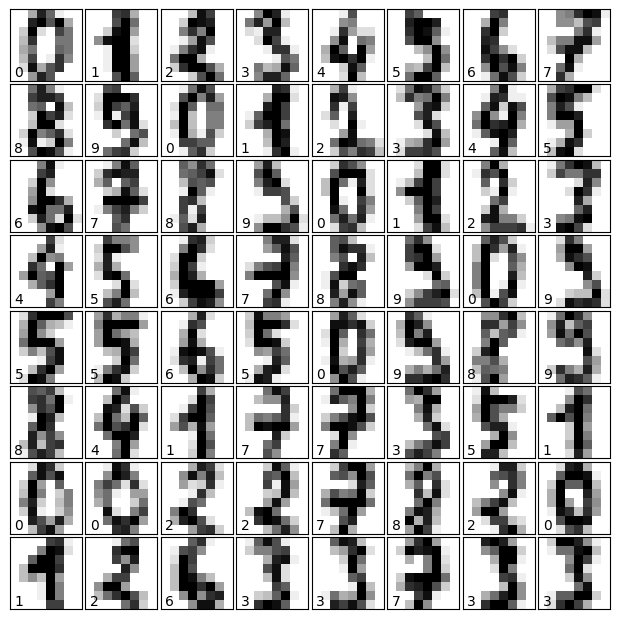

In [64]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

# 1. Cargar el dataset
digits = load_digits()

# Configurar el tamaño de la figura general
fig = plt.figure(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# Crear un ciclo para graficar los primeros 64 dígitos
for i in range(64):
    # Crear una subgráfica dentro de una cuadrícula de 8x8
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])

    # Mostrar la imagen del dígito usando la escala de grises/binaria
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')

    # Etiquetar la imagen con su valor real en la esquina inferior izquierda
    ax.text(0, 7, str(digits.target[i]), color='black')

plt.show()

In [65]:
from sklearn.model_selection import train_test_split

# Dividir los datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    digits.data,     # X: Las características (los arreglos de 64 píxeles)
    digits.target,   # y: Las etiquetas (los números reales del 0 al 9)
    test_size=0.2,   # Indica que el 20% es para pruebas (por ende, 80% entrenamiento)
    random_state=42  # Se usa una "semilla" fija para que los resultados no cambien cada vez que lo corras
)

# Imprimir los resultados para comprobar la división
print("--- División 80/20 completada ---")
print(f"Total de imágenes en el dataset original: {digits.data.shape[0]}")
print(f"Imágenes para Entrenamiento (X_train): {X_train.shape[0]}")
print(f"Imágenes para Prueba (X_test): {X_test.shape[0]}")

--- División 80/20 completada ---
Total de imágenes en el dataset original: 1797
Imágenes para Entrenamiento (X_train): 1437
Imágenes para Prueba (X_test): 360


In [66]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Instanciar los modelos
modelo_knn = KNeighborsClassifier(n_neighbors=3)
modelo_svm = SVC(kernel='rbf')
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar los modelos
modelo_knn.fit(X_train, y_train)
modelo_svm.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)

print("¡Los tres modelos han sido entrenados!")


¡Los tres modelos han sido entrenados!


In [67]:
from sklearn.metrics import accuracy_score

# 1. Los modelos generan sus predicciones sobre los datos de prueba que no conocen
pred_knn = modelo_knn.predict(X_test)
pred_svm = modelo_svm.predict(X_test)
pred_rf = modelo_rf.predict(X_test)

# 2. Comparamos sus predicciones con las respuestas reales (y_test)
acc_knn = accuracy_score(y_test, pred_knn)
acc_svm = accuracy_score(y_test, pred_svm)
acc_rf = accuracy_score(y_test, pred_rf)

# 3. Imprimimos las calificaciones
print("--- Resultados de Evaluación (Accuracy) ---")
print(f"Exactitud KNN (k=3):          {acc_knn * 100:.2f}%")
print(f"Exactitud SVM (kernel RBF):   {acc_svm * 100:.2f}%")
print(f"Exactitud Random Forest (100):{acc_rf * 100:.2f}%")

--- Resultados de Evaluación (Accuracy) ---
Exactitud KNN (k=3):          98.33%
Exactitud SVM (kernel RBF):   98.61%
Exactitud Random Forest (100):97.22%


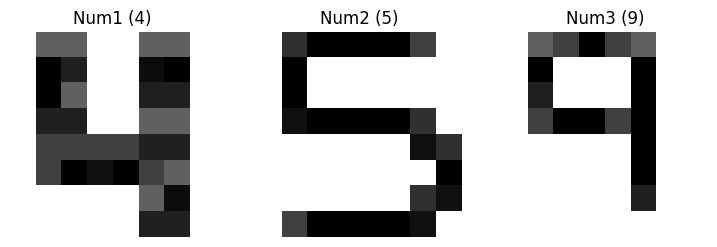

In [68]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def procesar_imagen_paint(ruta_imagen):
    # 1. Cargar la imagen y convertir a escala de grises ('L')
    img = Image.open(ruta_imagen).convert('L')

    # 2. Redimensionar a la matriz de 8x8 que requieren los modelos
    img_resized = img.resize((8, 8))

    # 3. Convertir la imagen a un arreglo matemático
    img_array = np.array(img_resized)

    # 4. Invertir colores: En Paint el blanco es 255 y negro es 0.
    # Queremos que el fondo sea 0 y el trazo tenga valor.
    img_invertida = 255 - img_array

    # 5. Cambiar la escala: de 0-255 a la escala de 0-16 de Scikit-Learn
    img_escalada = (img_invertida / 255.0) * 16

    # 6. Aplanar la matriz de 8x8 a un vector de 64 características
    img_final = img_escalada.reshape(1, -1)

    return img_final, img_resized

# Procesamos tus 3 archivos
img1_procesada, img1_vis = procesar_imagen_paint('Num1.png')
img2_procesada, img2_vis = procesar_imagen_paint('Num2.png')
img3_procesada, img3_vis = procesar_imagen_paint('Num3.png')

mis_imagenes = [img1_procesada, img2_procesada, img3_procesada]


fig, axes = plt.subplots(1, 3, figsize=(9, 3))
imagenes_vis = [img1_vis, img2_vis, img3_vis]
titulos = ["Num1 (4)", "Num2 (5)", "Num3 (9)"]

for ax, imagen, titulo in zip(axes, imagenes_vis, titulos):
    ax.imshow(imagen, cmap='gray')
    ax.set_title(titulo)
    ax.axis('off')

plt.show()

In [69]:
etiquetas_reales = [4, 5, 9]
for i in range(3):
    print(f"--- Evaluando Imagen {i+1} ---")
    print(f"Etiqueta Real: {etiquetas_reales[i]}")

    pred_knn = modelo_knn.predict(mis_imagenes[i])[0]
    pred_svm = modelo_svm.predict(mis_imagenes[i])[0]
    pred_rf = modelo_rf.predict(mis_imagenes[i])[0]

    print(f"Predicción KNN:          {pred_knn}")
    print(f"Predicción SVM:          {pred_svm}")
    print(f"Predicción Random Forest:{pred_rf}")
    print("-" * 40, "\n")

--- Evaluando Imagen 1 ---
Etiqueta Real: 4
Predicción KNN:          1
Predicción SVM:          4
Predicción Random Forest:9
---------------------------------------- 

--- Evaluando Imagen 2 ---
Etiqueta Real: 5
Predicción KNN:          9
Predicción SVM:          5
Predicción Random Forest:5
---------------------------------------- 

--- Evaluando Imagen 3 ---
Etiqueta Real: 9
Predicción KNN:          9
Predicción SVM:          9
Predicción Random Forest:9
---------------------------------------- 

